# B1 时间维度分析
分析各小时、工作日vs周末、每日趋势、时间段占比

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载清洗后数据
df = pd.read_csv('data/共享单车_清洗后.csv', parse_dates=['start_time', 'end_time'])

# 派生时间字段（如果不存在则创建）
df['start_hour'] = df['start_time'].dt.hour
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5
def period(h): return '早高峰' if 7<=h<9 else '晚高峰' if 17<=h<20 else '日间' if 9<=h<17 else '夜间'
df['time_period'] = df['start_hour'].map(period)

### 1. 各小时骑行量（高峰标红）

,start_hour,订单数
0,0,942
1,1,605
2,2,398
3,3,226
4,4,231
5,5,512
6,6,2290
7,7,6302
8,8,8477
9,9,5194


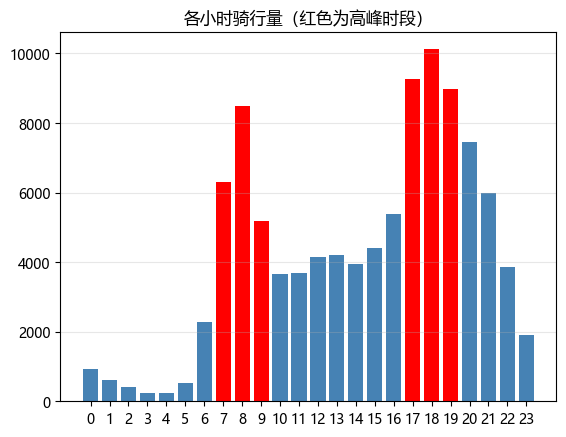

In [14]:
# 按小时聚合订单数
hourly = df.groupby('start_hour').size().reset_index(name='订单数')
display(hourly)  # 先显示数据表

# 绘图：高峰时段(7-9,17-19)标红
colors = ['red' if h in [7,8,9,17,18,19] else 'steelblue' for h in hourly['start_hour']]
plt.bar(hourly['start_hour'], hourly['订单数'], color=colors)
plt.title('各小时骑行量（红色为高峰时段）')
plt.xticks(range(0,24))
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. 工作日 vs 周末 每小时平均骑行量

,start_hour,is_weekend,count
0,0,False,26.347826
1,0,True,42.000000
2,1,False,16.000000
3,1,True,29.625000
4,2,False,10.863636
5,2,True,19.875000
6,3,False,7.476190
7,3,True,8.625000
8,4,False,8.272727
9,4,True,6.125000


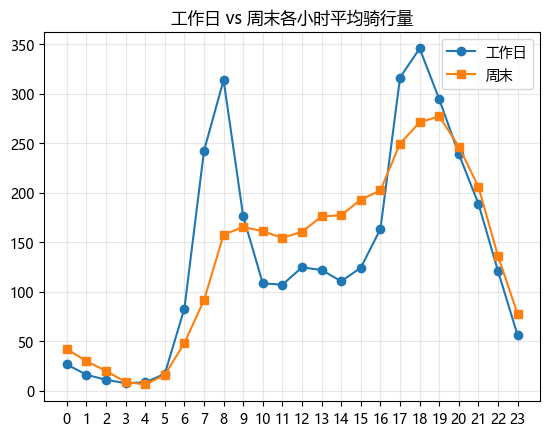

In [15]:
# 按日期+小时+是否周末聚合，再按小时和周末取平均
daily_hourly = df.groupby([df['start_time'].dt.date, 'start_hour', 'is_weekend']).size().reset_index(name='count')
avg = daily_hourly.groupby(['start_hour', 'is_weekend'])['count'].mean().reset_index()
display(avg.head(10))  # 显示部分

# 分离工作日和周末
work = avg[avg['is_weekend']==0]
week = avg[avg['is_weekend']==1]
plt.plot(work['start_hour'], work['count'], marker='o', label='工作日')
plt.plot(week['start_hour'], week['count'], marker='s', label='周末')
plt.legend(); plt.title('工作日 vs 周末各小时平均骑行量')
plt.xticks(range(0,24)); plt.grid(alpha=0.3)
plt.show()

### 3. 每日骑行量趋势

,日期,订单数
0,2016-08-01,1824
1,2016-08-02,1456
2,2016-08-03,1887
3,2016-08-04,1702
4,2016-08-05,1545
5,2016-08-06,2181
6,2016-08-07,2093
7,2016-08-08,2567
8,2016-08-09,2632
9,2016-08-10,2970


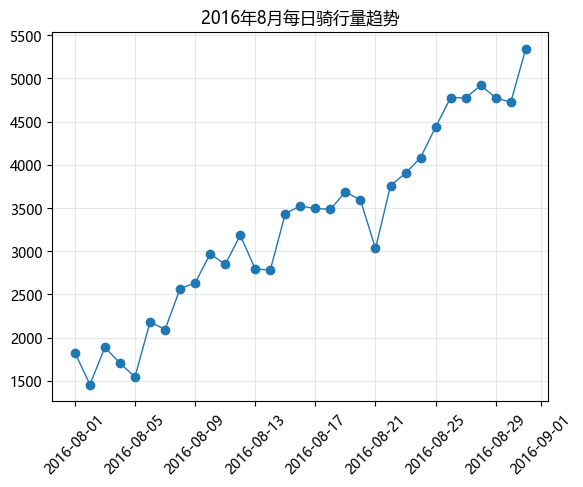

日均订单：3297，峰值：5346，谷值：1456


In [16]:
daily = df.groupby(df['start_time'].dt.date).size().reset_index(name='订单数')
daily.columns = ['日期', '订单数']
display(daily.head(10))

plt.plot(pd.to_datetime(daily['日期']), daily['订单数'], marker='o', linewidth=1)
plt.title('2016年8月每日骑行量趋势')
plt.xticks(rotation=45); plt.grid(alpha=0.3)
plt.show()
print(f"日均订单：{daily['订单数'].mean():.0f}，峰值：{daily['订单数'].max()}，谷值：{daily['订单数'].min()}")

### 4. 时间段占比（饼图）

time_period
日间     34645
晚高峰    28376
夜间     24410
早高峰    14779
Name: count, dtype: int64

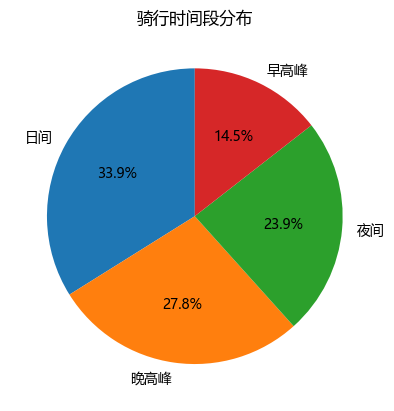

早高峰占比：19.5%，晚高峰占比：27.8%


In [17]:
period_cnt = df['time_period'].value_counts()
display(period_cnt)

plt.pie(period_cnt, labels=period_cnt.index, autopct='%1.1f%%', startangle=90)
plt.title('骑行时间段分布')
plt.show()
morning = df[df['start_hour'].between(7,9)].shape[0] / len(df) * 100
evening = df[df['start_hour'].between(17,19)].shape[0] / len(df) * 100
print(f"早高峰占比：{morning:.1f}%，晚高峰占比：{evening:.1f}%")